<a href="https://colab.research.google.com/github/HargunG/IntroToML/blob/main/Hargun_Kaur_Gill_HW3_KNN_Colab_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW3: K Nearest Neighbor and Naive Bayes Classification using Scikit-Learn

In this homework you will learn to train a K-Nearest Neighbor model and Naive Bayes using scikit-learn on the iris dataset.

# Ouline
- [1. Dataset](#1)
 - [1.1 Visualization using matplotlib](#2)
 - [1.2 Visualization using seaborn](#3)
- [2. K-Nearest Neighbor Implementation](#4)
 - [2.1 Fit the model](#5)
 - [2.2 Make Predictions and  Calculate accuracy](#6)
 - [2.3 Finding Optimal K value](#7)
- [3 Gaussian Naive Bayes Implementation](#8)
 - [3.1 Feature Scaling](#9)
 - [3.2 Fitting the Model](#10)
- [4. Plotting Decision Boundaries for KNN](#11)
- [5. Plotting Decision Boundaries for GNB](#12)


<a name="1"></a>
## 1- Dataset

Iris dataset is one of the most wellknown databasis for practicing the machine learning. Due to its popularity scikit-learn has provided access to it as part of its internal educational datasets. Let's start by importing the required dependencies associate with this exercise.

There are three different species
- setosa
- versicolor
- virginica

each species have certain features which are slightly different from each other

- sepal length
- sepal width
- petal length
- petal width

In this exercise you will use K-Nearest Neighbor and Naive Bayes to model these species classification.

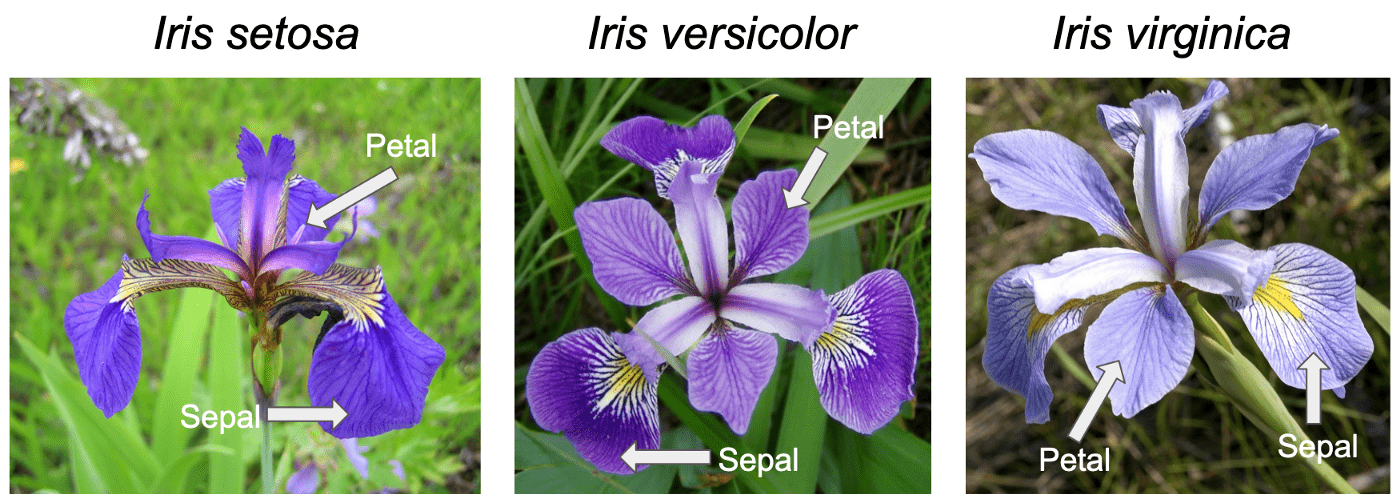



In [ ]:
import random
import math
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
#from sklearn.metrics import mean_squared_error
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

Now let's load the data and examine its content.

In [ ]:
iris = load_iris()
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


We would only be working with the features and target labels which are inside the `data` and `target` dictionary keys.
The list of the feature names and target labels can be found inside `feature_names` and `target_names` dictionary keys. Let's print them here.


In [ ]:
X = iris['data']
print(X.shape)
y = iris['target']
print(y.shape)
print("The name of Iris species are: ")
print(iris['target_names'])
print("The total number of data points are: %s"%X.shape[0])
print("There are %s differnt features named below"%X.shape[1])
print(iris['feature_names'])


(150, 4)
(150,)
The name of Iris species are: 
['setosa' 'versicolor' 'virginica']
The total number of data points are: 150
There are 4 differnt features named below
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


<a name="2"></a>
## 1.1 Visualization using matplotlib

Let's plot each feature against each other to get a glimps of the possible relationship between the features. We will be using matplotlib pacakge to do all the plots. Note the length of the code. Eventhogh someone could possibly write a loop and shorten this code, it still would look like lengthy and difficult to read.  



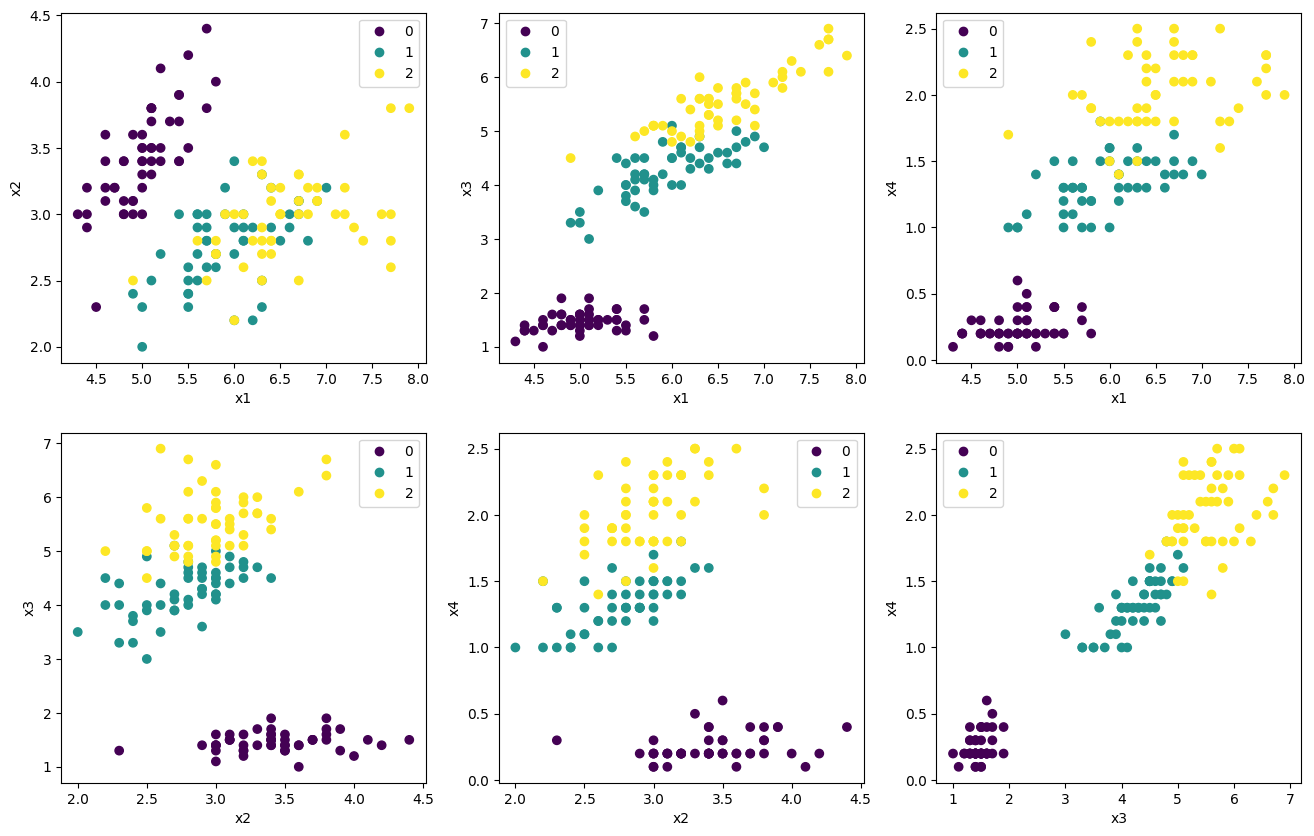

In [ ]:
plt.subplot(2,3,1)
scatter = plt.scatter(X[:,0],X[:,1], c=y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(*scatter.legend_elements())
plt.subplot(2,3,2)
scatter = plt.scatter(X[:,0],X[:,2], c=y)
plt.xlabel('x1')
plt.ylabel('x3')
plt.legend(*scatter.legend_elements())
plt.subplot(2,3,3)
scatter = plt.scatter(X[:,0],X[:,3], c=y)
plt.xlabel('x1')
plt.ylabel('x4')
plt.legend(*scatter.legend_elements())
plt.subplot(2,3,4)
scatter = plt.scatter(X[:,1],X[:,2], c=y)
plt.xlabel('x2')
plt.ylabel('x3')
plt.legend(*scatter.legend_elements())
plt.subplot(2,3,5)
scatter = plt.scatter(X[:,1],X[:,3], c=y)
plt.xlabel('x2')
plt.ylabel('x4')
plt.legend(*scatter.legend_elements())
plt.subplot(2,3,6)
scatter = plt.scatter(X[:,2],X[:,3], c=y)
plt.xlabel('x3')
plt.ylabel('x4')
plt.legend(*scatter.legend_elements())
fig = plt.gcf()
fig.set_size_inches(16, 10)
plt.show()

<a name="3"></a>
## 1.2 Visualization using seaborn

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

For a brief introduction to the ideas behind the library, you can read [the introductory notes](https://seaborn.pydata.org/tutorial/introduction.html) or the <a class="reference external" href="https://joss.theoj.org/papers/10.21105/joss.03021">paper</a>.

For this section of the exercise you need to do some reading on the function `pairplot`. Make sure you will read the material in this [link](https://seaborn.pydata.org/generated/seaborn.pairplot.html) first. You need them to answer the questions.



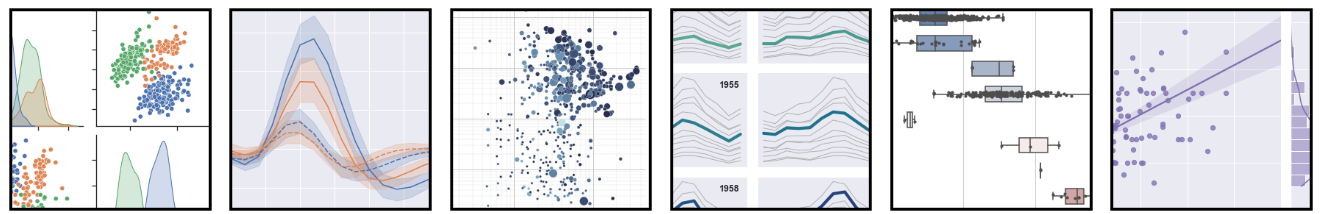

Seaborn is designed to work on datasets which have pandas data frame format. pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.

For more information visit the [pandas website](https://seaborn.pydata.org/tutorial/introduction.html).

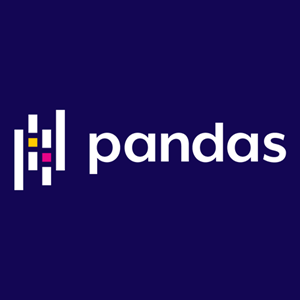

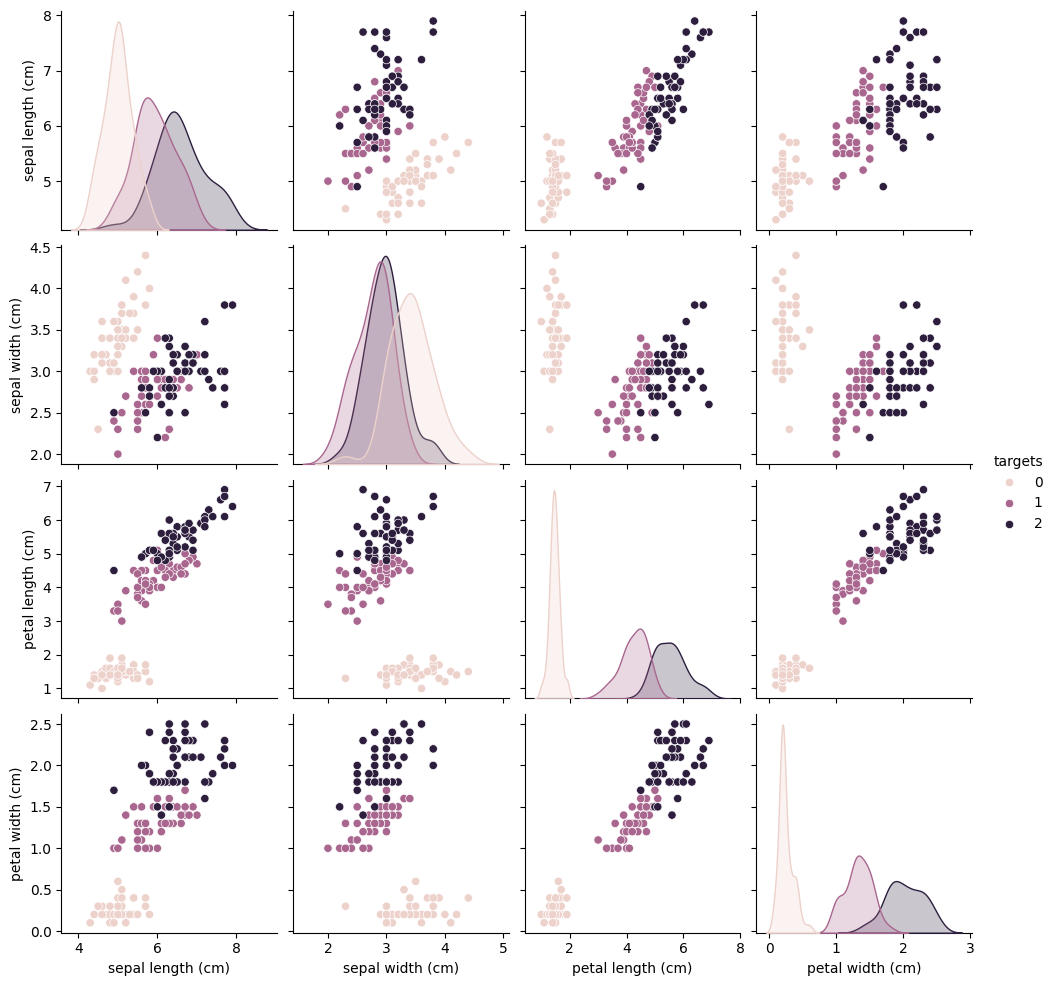

In [ ]:
# GRADED SECTION 30 points

### ADD A MARKUP BELLOW THIS CELL
### 1. explian what each plot on the diagonal sections are
### 2. Expain how the rest of the plots are related to the plots on the previous section.

import seaborn as sns
import pandas as pd
# this line will transform the matrix X into a data frame structure
df = pd.DataFrame(X, columns=iris['feature_names'])
# this line will add the targets y as a column to the data frame
df.insert(4, "targets", y)
# This simple line will do simply what we did previously and more!
sns.pairplot(df, hue="targets")

The **diagonal plots** are univariate distribution plots drawn to show the marginal distribution of the data in each column.

### First Diagonal Plot (Sepal Length):
* This plot shows the univariate distribution of sepal length for the three species: Setosa, Versicolor, and Virginica.
* Setosa (species 0) generally has the smallest sepal length, Virginica (species 2) has the largest, and Versicolor (species 1) falls in between.
*  Setosa stands out slightly due to its lower length values, but the classes do overlap.

### Second Diagonal Plot (Sepal Width):
* This plot shows the univariate distribution of sepal width for the three species: Setosa, Versicolor, and Virginica.
* Setosa (species 0) seems to have the highest sepal length with some overlap with the other two species, who also seem to have similar ranges.
* Setosa stands out slightly due to its higher width values, but the classes do overlap.

### Third Diagonal Plot (Petal Length):
* This plot shows the univariate distribution of Petal Length for the three species: Setosa, Versicolor, and Virginica.
* Setosa (species 0) seems to have the lowest sepal length when compared with the other two species and also stands out.
* Versicolor and Virginica have partially overlapping petal lengths, though Virginica's distribution tends to be higher overall.

### Fourth Diagonal Plot (Petal Width):
* This plot shows the univariate distribution of Petal Width for the three species: Setosa, Versicolor, and Virginica.
* Setosa (species 0) seems to have the lowest sepal Width when compared with the other two species and also stands out.
* Versicolor and Virginica have partially overlapping petal widths, though Virginica's distribution tends to be higher overall.


The **non-diagonal plots** in a pairplot are scatter plots for every pair of features. Each plot shows the relationship between two different features, colored by targets.

### Sepal Length vs. Sepal Width:

* This scatter plot shows the relationship between sepal length and sepal width for each species.
* Setosa (species 0) forms a distinct cluster with lower sepal length and higher sepal width, making it easily distinguishable from Versicolor and Virginica.
* Versicolor and Virginica overlap more, though Virginica tends to have slightly larger sepal lengths.

### Sepal Length vs. Petal Width:

* This scatter plot shows each species' relationship between sepal length and petal width.
* Setosa (species 0) forms a distinct cluster with lower sepal length and petal width, making it easily distinguishable from Versicolor and Virginica.
* Versicolor and Virginica overlap a little, but Virginica has generally higher petal width values, giving some partial separation.


### Sepal Width vs. Petal Length:

* This scatter plot shows each species' relationship between sepal width and petal length.
* Setosa (species 0) forms a distinct cluster with lower petal length and higher sepal width, making it easily distinguishable from Versicolor and Virginica.
* Versicolor and Virginica tend to overlap, though Virginica tends to have generally higher petal length.

### Sepal Width vs. Petal Width:

* This scatter plot shows each species' relationship between sepal and petal widths.
* Setosa (species 0) forms a distinct cluster with lower petal width and ranging sepal width values, making it easily distinguishable from Versicolor and Virginica.
* Versicolor and Virginica overlap slightly, though Virginica has a higher petal width than Versicolor and similar sepal widths.


### Petal Length vs. Sepal Length:

* This scatter plot shows the relationship between each species' petal length and sepal length.
* Setosa (species 0) forms a distinct cluster with lower sepal and petal lengths, making it easily distinguishable from Versicolor and Virginica.
* Versicolor and Virginica overlap more, though Virginica tends to have slightly larger sepal and petal lengths.


### Petal Length vs. Petal Width:

* This scatter plot shows the relationship between each species' petal length and petal width.
* Setosa (species 0) forms a distinct cluster with low values in both petal length and width, making it easily distinguishable from Versicolor and Virginica.
* Versicolor and Virginica overlap slightly, though Virginica tends to have larger petal lengths and widths than Versicolor.



<a name="4"></a>
## 2. K-Nearest Neighbor Implementation


### Split data into training set and test sets

Let's split our data into a training and test sets. We choose only 20% of the data for the test purposes.


In [ ]:
#Split the data into 80% training set and 20% test set randomly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print(X_train.shape)
print(X_test.shape)

(120, 4)
(30, 4)


<a name="5"></a>
## 2.1 Fit the model

The code below uses the [K-Nearest Neighbor classification model](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) from scikit-learn. This code only uses 1NN. In the next section you will modify it and test its accuracy against different K. You can fit this model on the training data by calling `fit` function.

In [ ]:
#Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=1)

#Train the model using the training sets
knn.fit(X_train, y_train)

print("Accuracy on training set:", knn.score(X_train, y_train))

Accuracy on training set: 1.0


<a name="6"></a>
## 2.2 Make Predictions and  Calculate accuracy

You can see the predictions made by this model by calling the `predict` function. You can calculate this accuracy of this model by calling the `score` function.


In [ ]:
#Predict the response for test dataset
y_pred = knn.predict(X_test)

print("Prediction on test set:           ", y_pred)
print("Actual target values for test set:", y_test)


Prediction on test set:            [2 0 2 2 2 1 2 0 0 1 0 0 0 1 2 0 1 0 0 2 0 2 1 0 0 0 0 0 0 2]
Actual target values for test set: [2 0 2 2 2 1 1 0 0 2 0 0 0 1 2 0 1 0 0 2 0 2 1 0 0 0 0 0 0 2]


<a name="7"></a>
## 2.3 Finding Optimal K value

In the class we showed that lower K values correspond to high variances and higher K values correspond to high biases. In this section you need to write a simple loop to fit our data using different values of K. You should get resutls similar to the following plot.

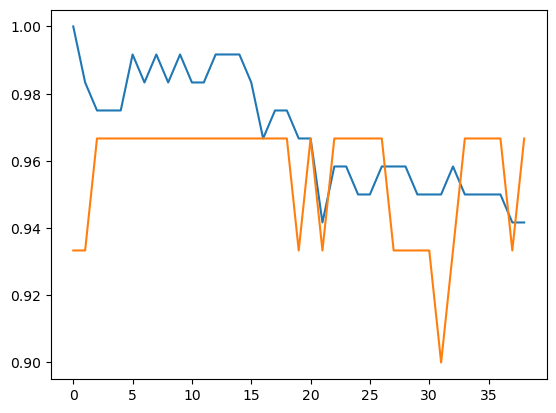

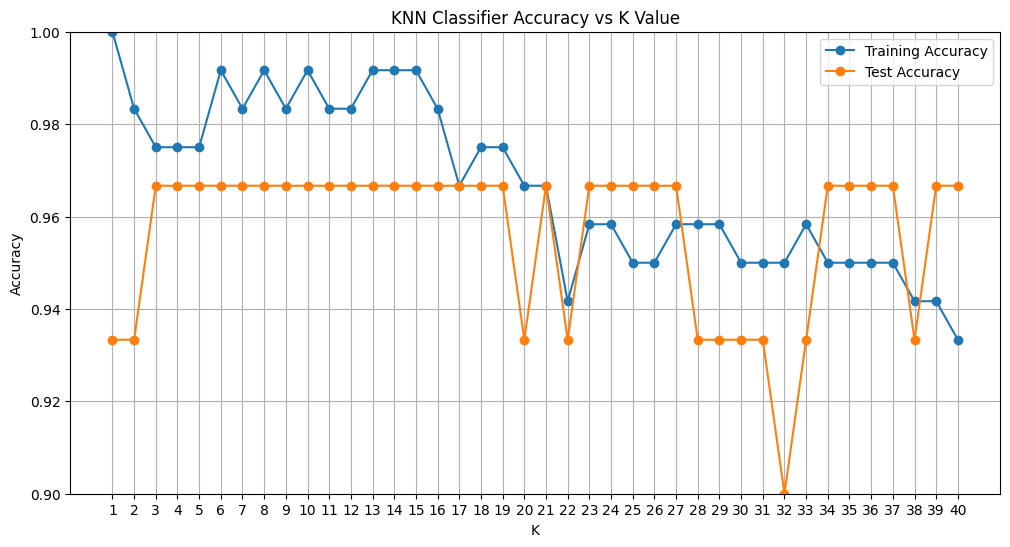

In [ ]:
# GRADED SECTION 40 points

### 1. Write a loop which changes the K value from 1 to 40 and then measures
###      the accuracy of the training and test sets and record them in an array
### 2. plot the accuracy values of training and test set against different K value
### 3. based on the resutls which K is the best? Explain the reason behind your choice
### CODE STARTS HERE
train_accuracy_list, test_accuracy_list = [], []

for k in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracy = knn.score(X_train, y_train)
    test_accuracy = knn.score(X_test, y_test)
    train_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)


plt.figure(figsize=(12,6))
plt.plot(range(1, 41), train_accuracy_list, label='Training Accuracy',marker='o')
plt.plot(range(1, 41), test_accuracy_list, label='Test Accuracy',marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('KNN Classifier Accuracy vs K Value')
plt.xticks(range(1, 41))
plt.ylim(0.9,1)
plt.grid()
plt.legend()
plt.show()
### CODE ENDS HERE

The best value for K would be less than 15 and more than 5. After 15 the training accuracy keeps decreasing. Maybe 6 is the best option as it has the best training and test accuracies. The ideal K should maximize Test Accuracy while keeping the Training Accuracy high. It seems to offers high accuracy without overfitting on the training data and underfitting on the test data.

<a name="8"></a>
## 3. Gaussian Naive Bayes Implementation

The code below uses the [Gaussian Naive Bayes classification model](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html) from scikit-learn. Similar to KNN we will try to fit the Navie Basyes model to our training and test data and find the accuracy. But before that we will use scaling method.

<a name="9"></a>
## 3.1 Feature Scaling

We did talk about different forms of feature scaling in the class. They were generally improving the convergence of fitting algorithm such as Gradient Descent. We will implement the z-score feature scaling using the [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) from the preprocessing module of the scikit-learn.

In [ ]:
sc = StandardScaler()
sc.fit_transform(X_train)
X_train_norm = sc.transform(X_train)
X_test_norm = sc.transform(X_test)
X_norm = sc.transform(X)

print(X_train[:2,:])
print(X_train_norm[:2,:])

[[5.4 3.  4.5 1.5]
 [4.6 3.2 1.4 0.2]]
[[-0.59919456 -0.12779977  0.36033386  0.31743078]
 [-1.57913797  0.35144936 -1.47337606 -1.43236433]]


<a name="10"></a>
## 3.2 Fitting the Model

Now let's implement the Gaussian Naive Bayes classifier on the iris dataset.

In [ ]:
#Create Gaussian Naive Bayes Classifier
gnb = GaussianNB()

#Train the model using the training sets
gnb.fit(X_train_norm, y_train)

print("Accuracy on training set:", gnb.score(X_train_norm, y_train))
print("Accuracy on test set:", gnb.score(X_test_norm, y_test))

Accuracy on training set: 0.9583333333333334
Accuracy on test set: 0.9666666666666667


<a name="11"></a>

## 4. Plotting Decision Boundaries for KNN

In this section we will use only the first two features of our data set and plot the decision boundaries for both KNN model.

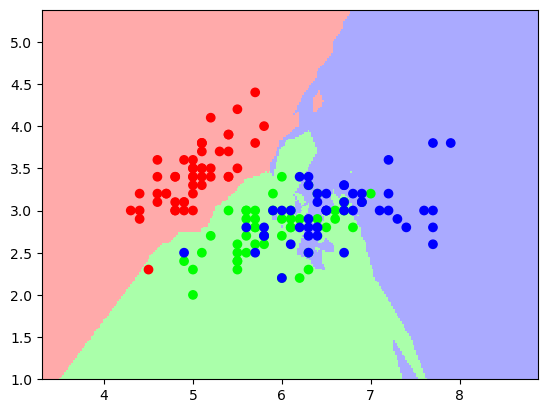

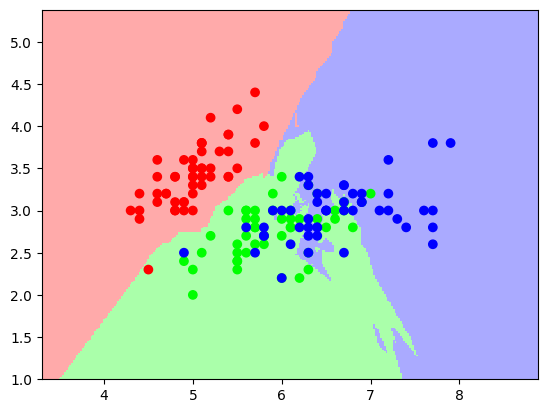

In [ ]:
# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

knn = KNeighborsClassifier(n_neighbors=6)
#Train the model on the first two features using the training sets
knn.fit(X_train[:,:2], y_train)
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].
h=.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.show()

<a name="12"></a>

## 4. Plotting Decision Boundaries for GNB

Modify the code above to plot the decision boundary for the Gaussian Naive Bayes classifier. Similar to the previous case use only the first two features of our data set.

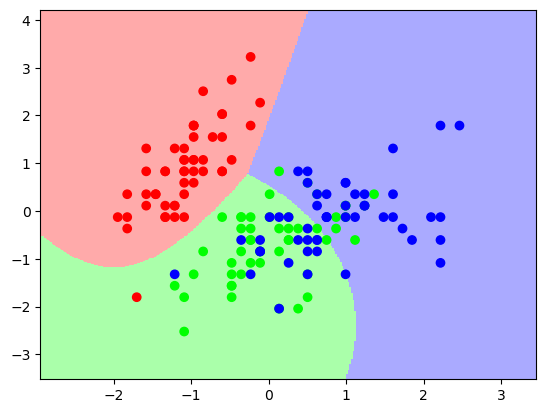




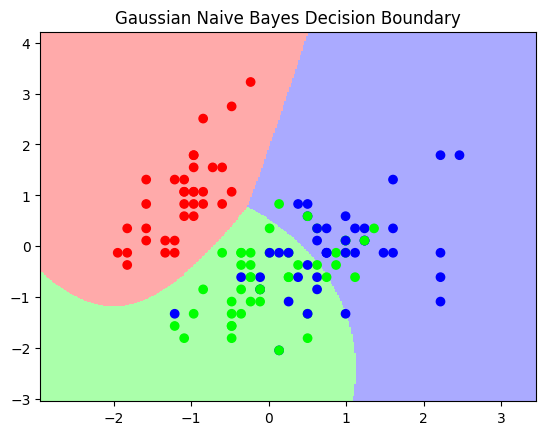

In [ ]:
# GRADED SECTION 30 points

GNB = GaussianNB()

#Train the model using the training sets
GNB.fit(X_train_norm[:,:2], y_train)
# Plot the decision boundary. For that, we will assign a color to each
# point in the mesh [x_min, x_max]x[y_min, y_max].

# Create color maps
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

h=.02
x_min, x_max = X_train_norm[:, 0].min() - 1, X_train_norm[:, 0].max() + 1
y_min, y_max = X_train_norm[:, 1].min() - 1, X_train_norm[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = GNB.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X_train_norm[:, 0], X_train_norm[:, 1], c=y_train, cmap=cmap_bold)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Gaussian Naive Bayes Decision Boundary')
plt.show()